In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/Top_12_German_Companies_Financial_Data.csv")

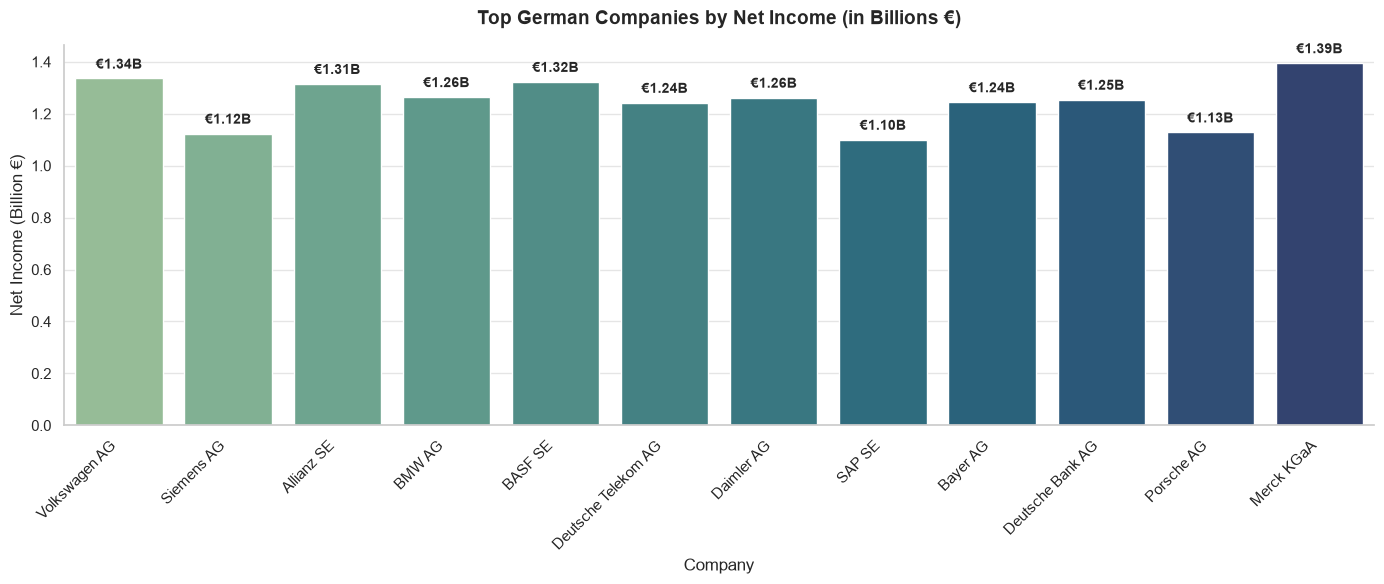

In [5]:
os.makedirs('../outputs', exist_ok=True)
df['Net_Income_Billion'] = df['Net Income'] / 1e9

fig, ax = plt.subplots(figsize=(14, 6))

ax = sns.barplot(
    data=df,
    x='Company',
    y='Net_Income_Billion',
    hue='Company',
    legend=False,
    palette='crest',
    errorbar=None
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'€{height:.2f}B',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # rastojanie nagore
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')


plt.title('Top German Companies by Net Income (in Billions €)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Net Income (Billion €)', fontsize=12)
plt.xticks(rotation=45, ha='right')


sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig('../outputs/german_companies_net_income.png', dpi=300, bbox_inches='tight')
plt.show()